In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HP\Downloads\EDA2\EDA2\adult_with_headers.csv")
df.head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [3]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [4]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [5]:
df_raw=df.copy()
print(df_raw)
df_numeric=df_raw.select_dtypes(include='int64')
#df_numeric.drop(['income'],axis=1)

       age          workclass  fnlwgt    education  education_num  \
0       39          State-gov   77516    Bachelors             13   
1       50   Self-emp-not-inc   83311    Bachelors             13   
2       38            Private  215646      HS-grad              9   
3       53            Private  234721         11th              7   
4       28            Private  338409    Bachelors             13   
...    ...                ...     ...          ...            ...   
32556   27            Private  257302   Assoc-acdm             12   
32557   40            Private  154374      HS-grad              9   
32558   58            Private  151910      HS-grad              9   
32559   22            Private  201490      HS-grad              9   
32560   52       Self-emp-inc  287927      HS-grad              9   

            marital_status          occupation    relationship    race  \
0            Never-married        Adm-clerical   Not-in-family   White   
1       Married-civ-spo

In [6]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df_numeric_scaled=scaler.fit_transform(df_numeric)
df_numeric_scaled

array([[ 0.03067056, -1.06361075,  1.13473876,  0.1484529 , -0.21665953,
        -0.03542945],
       [ 0.83710898, -1.008707  ,  1.13473876, -0.14592048, -0.21665953,
        -2.22215312],
       [-0.04264203,  0.2450785 , -0.42005962, -0.14592048, -0.21665953,
        -0.03542945],
       ...,
       [ 1.42360965, -0.35877741, -0.42005962, -0.14592048, -0.21665953,
        -0.03542945],
       [-1.21564337,  0.11095988, -0.42005962, -0.14592048, -0.21665953,
        -1.65522476],
       [ 0.98373415,  0.92989258, -0.42005962,  1.88842434, -0.21665953,
        -0.03542945]], shape=(32561, 6))

In [7]:
#ONE HOT ENCODING for categorical variables with less than or equal to 5 categories

df_encoded = pd.get_dummies(df_raw,columns=['race','sex'],dtype=int)
df_encoded

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,income,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,40,United-States,<=50K,0,0,0,0,1,0,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13,United-States,<=50K,0,0,0,0,1,0,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40,United-States,<=50K,0,0,0,0,1,0,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40,United-States,<=50K,0,0,1,0,0,0,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40,Cuba,<=50K,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,0,0,38,United-States,<=50K,0,0,0,0,1,1,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,0,0,40,United-States,>50K,0,0,0,0,1,0,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,0,0,40,United-States,<=50K,0,0,0,0,1,1,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,0,0,20,United-States,<=50K,0,0,0,0,1,0,1


In [8]:
#LABEL ENCODING for categorical variables with with more than 5 categories
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
df_encoded['encoded_workclass'] = label_encoder.fit_transform(df_encoded['workclass'])
#df_encoded['encoded_education'] = label_encoder.fit_transform(df_encoded['education'])
df_encoded['encoded_marital_status'] = label_encoder.fit_transform(df_encoded['marital_status'])
df_encoded['encoded_occupation'] = label_encoder.fit_transform(df_encoded['occupation'])
df_encoded['encoded_relationship'] = label_encoder.fit_transform(df_encoded['relationship'])
df_encoded

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,encoded_workclass,encoded_marital_status,encoded_occupation,encoded_relationship
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,...,0,0,0,1,0,1,7,4,1,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,...,0,0,0,1,0,1,6,2,4,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,...,0,0,0,1,0,1,4,0,6,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,...,0,1,0,0,0,1,4,2,6,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,...,0,1,0,0,1,0,4,2,10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,0,0,...,0,0,0,1,1,0,4,2,13,5
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,0,0,...,0,0,0,1,0,1,4,2,7,0
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,0,0,...,0,0,0,1,1,0,4,6,1,4
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,0,0,...,0,0,0,1,0,1,4,4,1,3


In [9]:
df['marital_status'].unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [10]:
df['relationship'].unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [11]:
# Run this to debug
print(f"One row looks like: {df['age']}")
print(f"Total columns in this tuple: {len(df['age'])}")

One row looks like: 0        39
1        50
2        38
3        53
4        28
         ..
32556    27
32557    40
32558    58
32559    22
32560    52
Name: age, Length: 32561, dtype: int64
Total columns in this tuple: 32561


In [12]:
df_encoded['capital_flux']=df['capital_gain']-df['capital_loss']
df_encoded

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,encoded_workclass,encoded_marital_status,encoded_occupation,encoded_relationship,capital_flux
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,...,0,0,1,0,1,7,4,1,1,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,...,0,0,1,0,1,6,2,4,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,...,0,0,1,0,1,4,0,6,1,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,...,1,0,0,0,1,4,2,6,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,...,1,0,0,1,0,4,2,10,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,0,0,...,0,0,1,1,0,4,2,13,5,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,0,0,...,0,0,1,0,1,4,2,7,0,0
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,0,0,...,0,0,1,1,0,4,6,1,4,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,0,0,...,0,0,1,0,1,4,4,1,3,0


The original dataset provides capital-gain and capital-loss as two separate columns. For many individuals, one of these is zero. However, for active investors, having both creates a "noisy" signal for the model.

Income is often a reflection of Net Wealth movement. A person who gained 10k but lost 8k has a net "Capital Flux" of $2k.
This feature collapses two sparse columns into a single, high-variance feature that directly represents an individual's financial surplus. High positive values are extremely strong predictors for the 50k income bracket, as lower-income individuals rarely have enough disposable income to generate significant capital movement.

In [13]:
import numpy as np

# Step 1: Force clean the strings (Handles the ' Husband' vs 'Husband' issue)
df_encoded['relationship'] = df_encoded['relationship'].astype(str).str.strip()
df_encoded['marital_status'] = df_encoded['marital_status'].astype(str).str.strip()

# Step 2: Define conditions
cond_3 = df_encoded['relationship'].isin(['Husband', 'Wife'])

cond_2 = (df_encoded['relationship'].isin(['Unmarried', 'Not-in-family'])) & (df_encoded['marital_status'].isin(['Divorced', 'Separated', 'Widowed', 'Married-spouse-absent']))

cond_1 = (df_encoded['relationship'] == 'Own-child') | (df_encoded['marital_status'] == 'Never-married')

# Step 3: Apply
df_encoded['household_responsibility'] = np.select([cond_3, cond_2, cond_1], [3, 2, 1], default=1)

# Step 4: Verify the counts
df_encoded

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,race_ Other,race_ White,sex_ Female,sex_ Male,encoded_workclass,encoded_marital_status,encoded_occupation,encoded_relationship,capital_flux,household_responsibility
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,...,0,1,0,1,7,4,1,1,2174,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,...,0,1,0,1,6,2,4,0,0,3
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,...,0,1,0,1,4,0,6,1,0,2
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,...,0,0,0,1,4,2,6,0,0,3
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,...,0,0,1,0,4,2,10,5,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,0,0,...,0,1,1,0,4,2,13,5,0,3
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,0,0,...,0,1,0,1,4,2,7,0,0,3
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,0,0,...,0,1,1,0,4,6,1,4,0,2
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,0,0,...,0,1,0,1,4,4,1,3,0,1


Income in the Adult dataset is highly correlated with household stability. A "Married-Head" typically represents a dual-income or stable household, which is a massive predictor for the 50k category. Combining these removes the redundancy where "Husband" almost always implies "Married."

Handling Redundancy: In the original dataset, relationship='Husband' almost perfectly correlates with marital-status='Married-civ-spouse'. By combining them, you reduce multicollinearity, which helps models like Logistic Regression stay stable.
Capturing Latent Features: This score acts as a proxy for Financial Stability. Statistically, in the Adult dataset, individuals with a "High" score (3) have a significantly higher probability of earning 50k.
Ordinal Encoding: By using numbers (1, 2, 3), you allow the model to understand the magnitude of responsibility. 

In [14]:
# We use np.sign to keep the direction (gain or loss) 
# and np.log1p to handle the many 0.0 values safely.
df_encoded['capital_flux_log'] = np.sign(df_encoded['capital_flux']) * np.log1p(df_encoded['capital_flux'].abs())

# Verify the result
print(df_encoded[['capital_flux', 'capital_flux_log']].describe())

       capital_flux  capital_flux_log
count  32561.000000      32561.000000
mean     990.345014          0.384316
std     7408.986951          3.008543
min    -4356.000000         -8.379539
25%        0.000000          0.000000
50%        0.000000          0.000000
75%        0.000000          0.000000
max    99999.000000         11.512925


In [15]:
df_encoded

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,...,race_ White,sex_ Female,sex_ Male,encoded_workclass,encoded_marital_status,encoded_occupation,encoded_relationship,capital_flux,household_responsibility,capital_flux_log
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,...,1,0,1,7,4,1,1,2174,1,7.684784
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,...,1,0,1,6,2,4,0,0,3,0.000000
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,...,1,0,1,4,0,6,1,0,2,0.000000
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,...,0,0,1,4,2,6,0,0,3,0.000000
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,...,0,1,0,4,2,10,5,0,3,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,0,0,...,1,1,0,4,2,13,5,0,3,0.000000
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,0,0,...,1,0,1,4,2,7,0,0,3,0.000000
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,0,0,...,1,1,0,4,6,1,4,0,2,0.000000
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,0,0,...,1,0,1,4,4,1,3,0,1,0.000000


In [16]:
from sklearn.ensemble import IsolationForest

# 1. Select the numerical columns to check for outliers
# Including your new engineered features
num_cols = ['age', 'hours_per_week', 'capital_flux_log', 'household_responsibility']
#df_numeric_1=df_encoded.select_dtypes(include='int64')

# 2. Initialize the model
# contamination=0.05 means we expect about 5% of the data to be outliers
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# 3. Fit and Predict
# returns 1 for inliers and -1 for outliers
outlier_preds = iso_forest.fit_predict(df_encoded[num_cols])

# 4. Filter the DataFrame
df_cleaned = df_encoded[outlier_preds == 1].reset_index(drop=True)

print(f"Rows before: {len(df_encoded)}")
print(f"Rows after: {len(df_cleaned)}")
print(f"Outliers removed: {len(df_encoded) - len(df_cleaned)}")

Rows before: 32561
Rows after: 30933
Outliers removed: 1628


Outliers may cause machine learning models to overfit or learn incorrect patterns from rare extreme values.
Eliminating irrelevant outliers makes models easier to interpret and enhances their generalization to new data.

In [17]:
df_cleaned.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'capital_gain',
       'capital_loss', 'hours_per_week', 'native_country', 'income',
       'race_ Amer-Indian-Eskimo', 'race_ Asian-Pac-Islander', 'race_ Black',
       'race_ Other', 'race_ White', 'sex_ Female', 'sex_ Male',
       'encoded_workclass', 'encoded_marital_status', 'encoded_occupation',
       'encoded_relationship', 'capital_flux', 'household_responsibility',
       'capital_flux_log'],
      dtype='object')

In [18]:
!pip uninstall scipy -y

Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1


You can safely remove it manually.
You can safely remove it manually.


In [19]:
!pip install scipy

  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)


In [20]:
!pip install --force-reinstall scipy

  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl (12.3 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.4.3

    Uninstalling numpy-2.4.3:

   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-2.4.3
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   --------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.3 which is incompatible.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.


In [21]:
!pip install -U ppscore

In [22]:
import ppscore as pps
print(pps.__version__)

1.3.1


In [23]:
pps.score(df_cleaned, "capital_gain", "income")

{'x': 'capital_gain',
 'y': 'income',
 'ppscore': np.float64(0.23853714018170508),
 'case': 'classification',
 'is_valid_score': True,
 'metric': 'weighted F1',
 'baseline_score': 0.6598873936230568,
 'model_score': np.float64(0.7410168820879588),
 'model': DecisionTreeClassifier()}

In [24]:
pps.score(df_cleaned, "age", "income")

{'x': 'age',
 'y': 'income',
 'ppscore': np.float64(0.059908937974909184),
 'case': 'classification',
 'is_valid_score': True,
 'metric': 'weighted F1',
 'baseline_score': 0.6598873936230568,
 'model_score': np.float64(0.6802631786629778),
 'model': DecisionTreeClassifier()}

In [25]:
pps.score(df_cleaned, "occupation", "income")

{'x': 'occupation',
 'y': 'income',
 'ppscore': np.float64(1.288334642662118e-07),
 'case': 'classification',
 'is_valid_score': True,
 'metric': 'weighted F1',
 'baseline_score': 0.6598873936230568,
 'model_score': np.float64(0.6598874374409421),
 'model': DecisionTreeClassifier()}

In [26]:
matrix_df = pps.matrix(df_cleaned)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklea

In [27]:
matrix_df

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.000000,predict_itself,True,None,0.00000,1.000000,None
1,age,workclass,0.009119,classification,True,weighted F1,0.58407,0.587863,DecisionTreeClassifier()
2,age,fnlwgt,0.000000,regression,True,mean absolute error,76959.89440,78352.987311,DecisionTreeRegressor()
3,age,education,0.051443,classification,True,weighted F1,0.18180,0.223891,DecisionTreeClassifier()
4,age,education_num,0.000000,regression,True,mean absolute error,1.85960,1.913694,DecisionTreeRegressor()
...,...,...,...,...,...,...,...,...,...
724,capital_flux_log,encoded_occupation,0.000000,regression,True,mean absolute error,3.71320,3.767251,DecisionTreeRegressor()
725,capital_flux_log,encoded_relationship,0.000000,regression,True,mean absolute error,1.30940,1.416416,DecisionTreeRegressor()
726,capital_flux_log,capital_flux,0.995210,regression,True,mean absolute error,598.44780,2.866600,DecisionTreeRegressor()
727,capital_flux_log,household_responsibility,0.083096,regression,True,mean absolute error,0.82300,0.754612,DecisionTreeRegressor()


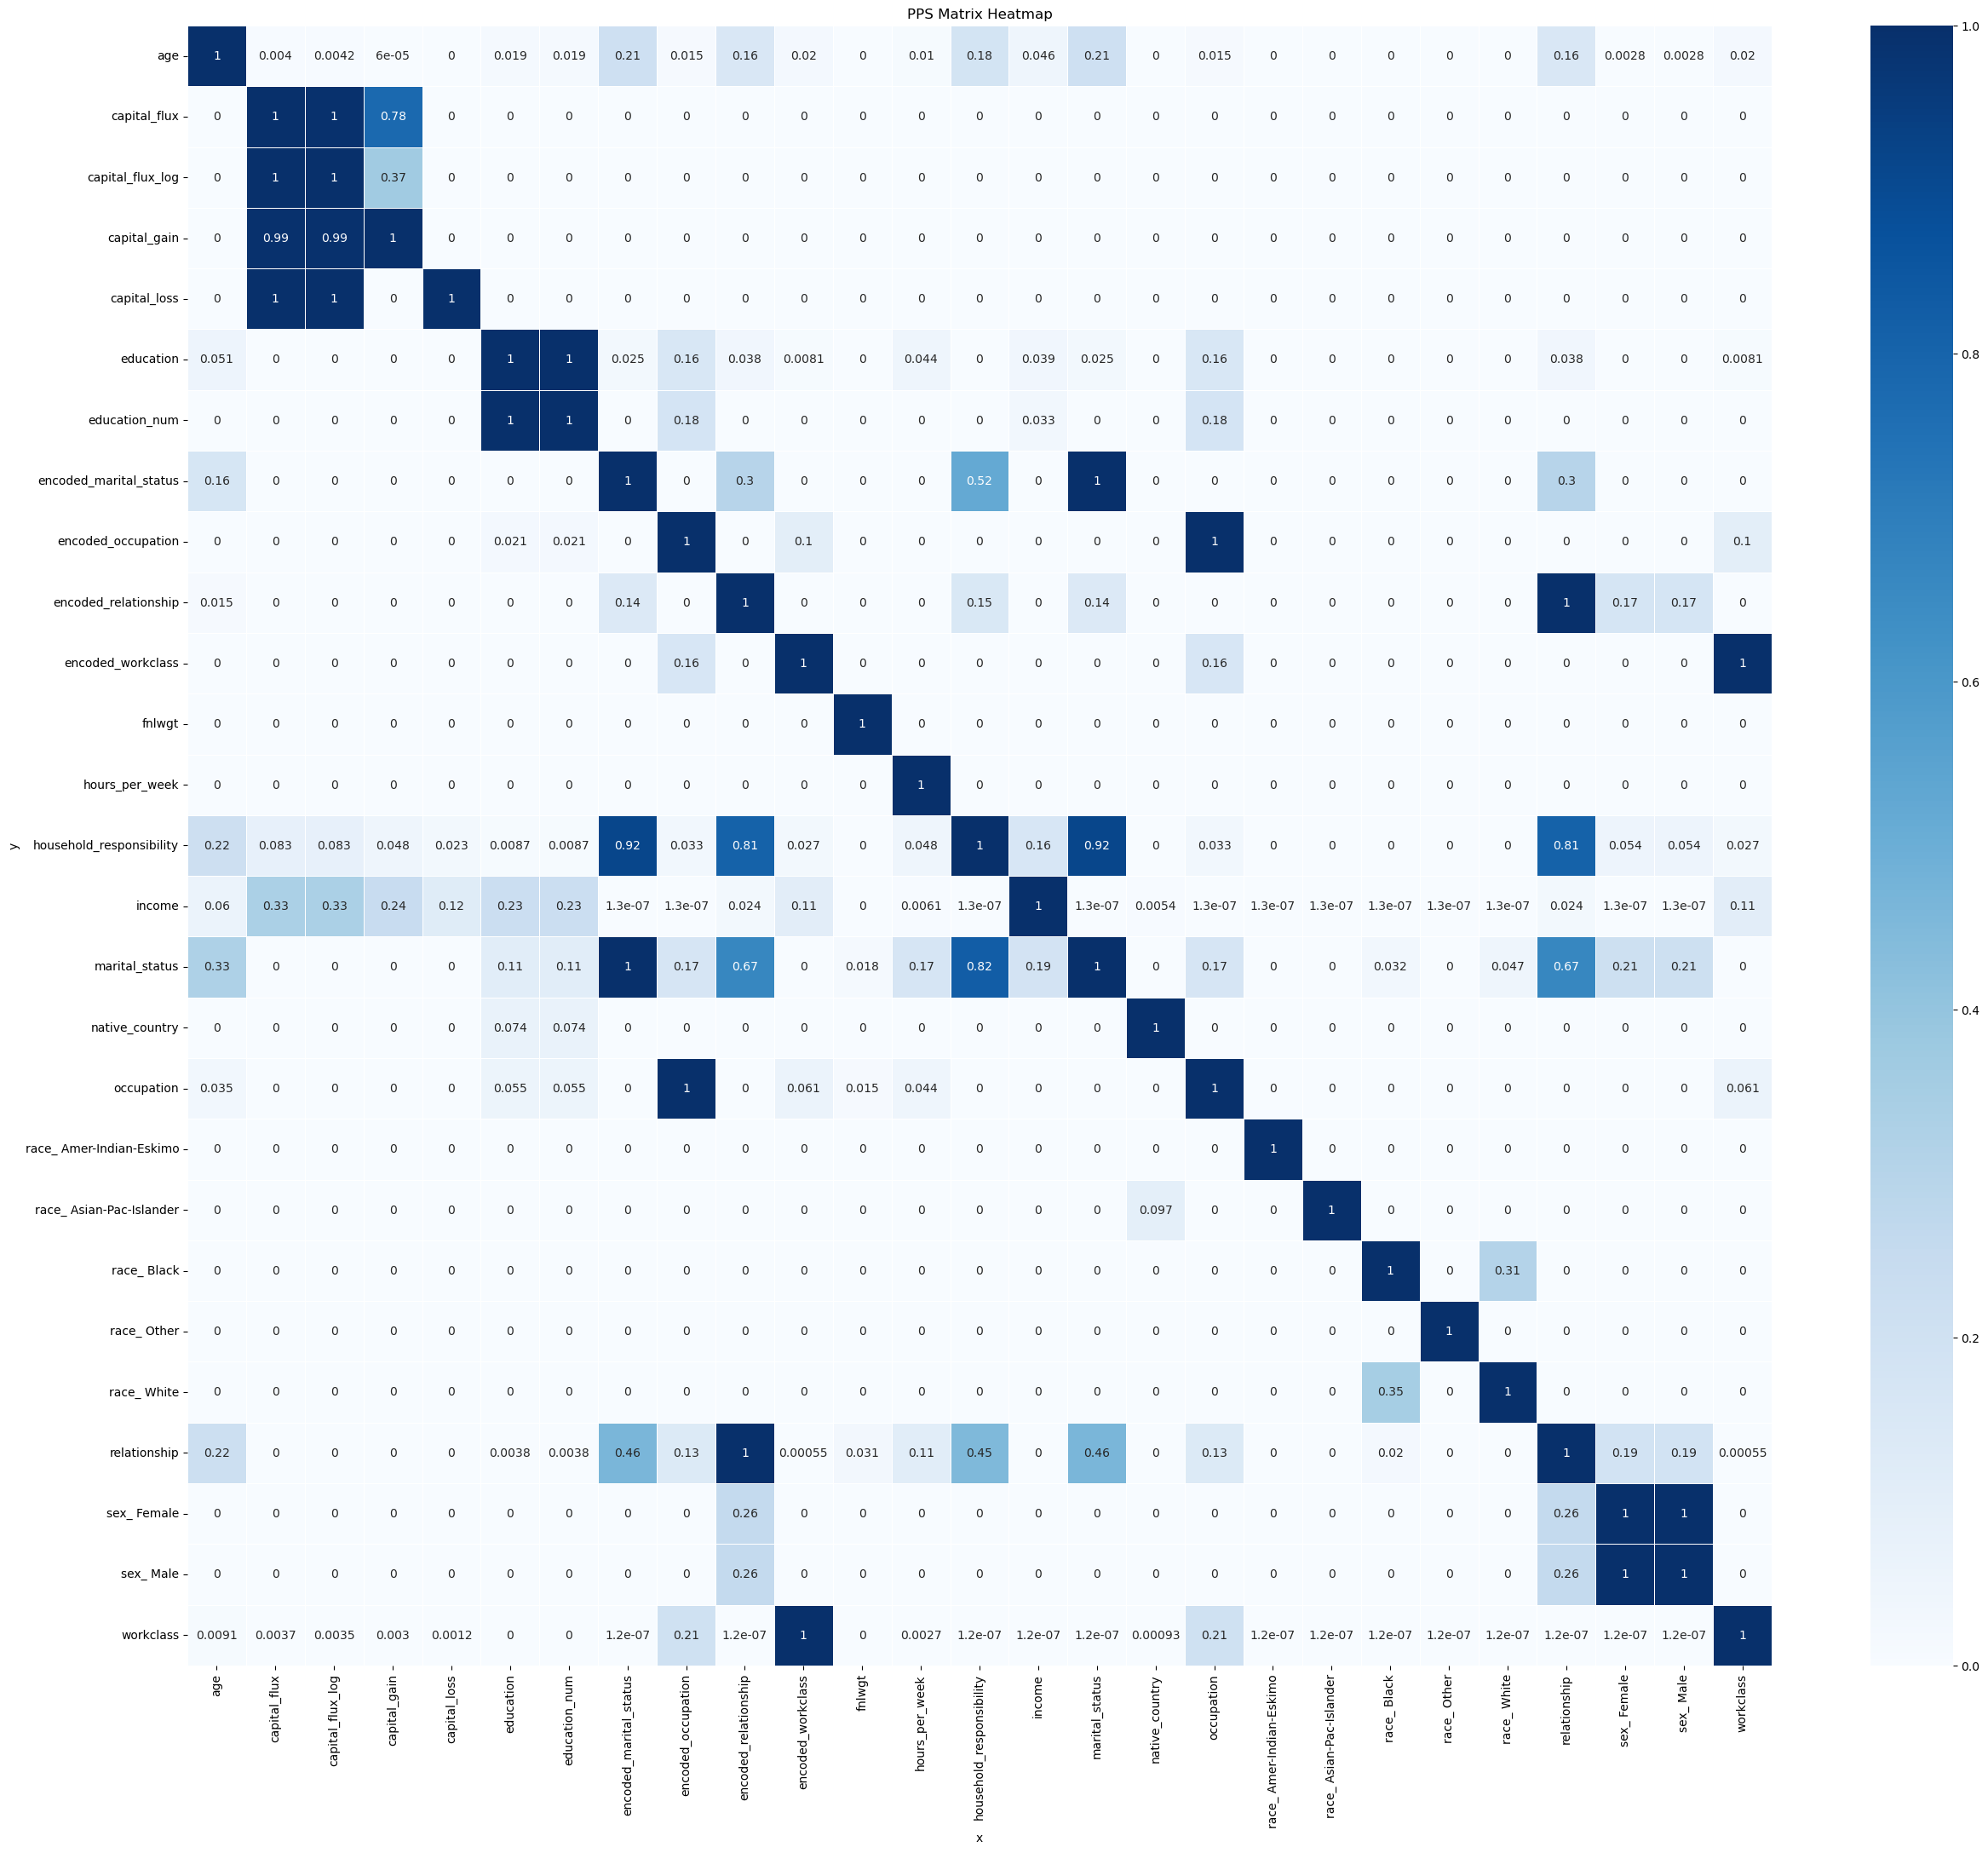

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
matrix_pivot = matrix_df[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')

# Visualize the PPS matrix with a heatmap
plt.figure(figsize=(30, 25))
sns.heatmap(matrix_pivot, vmin=0, vmax=1, cmap="Blues", linewidths=0.5, annot=True)
plt.title("PPS Matrix Heatmap")
plt.show()

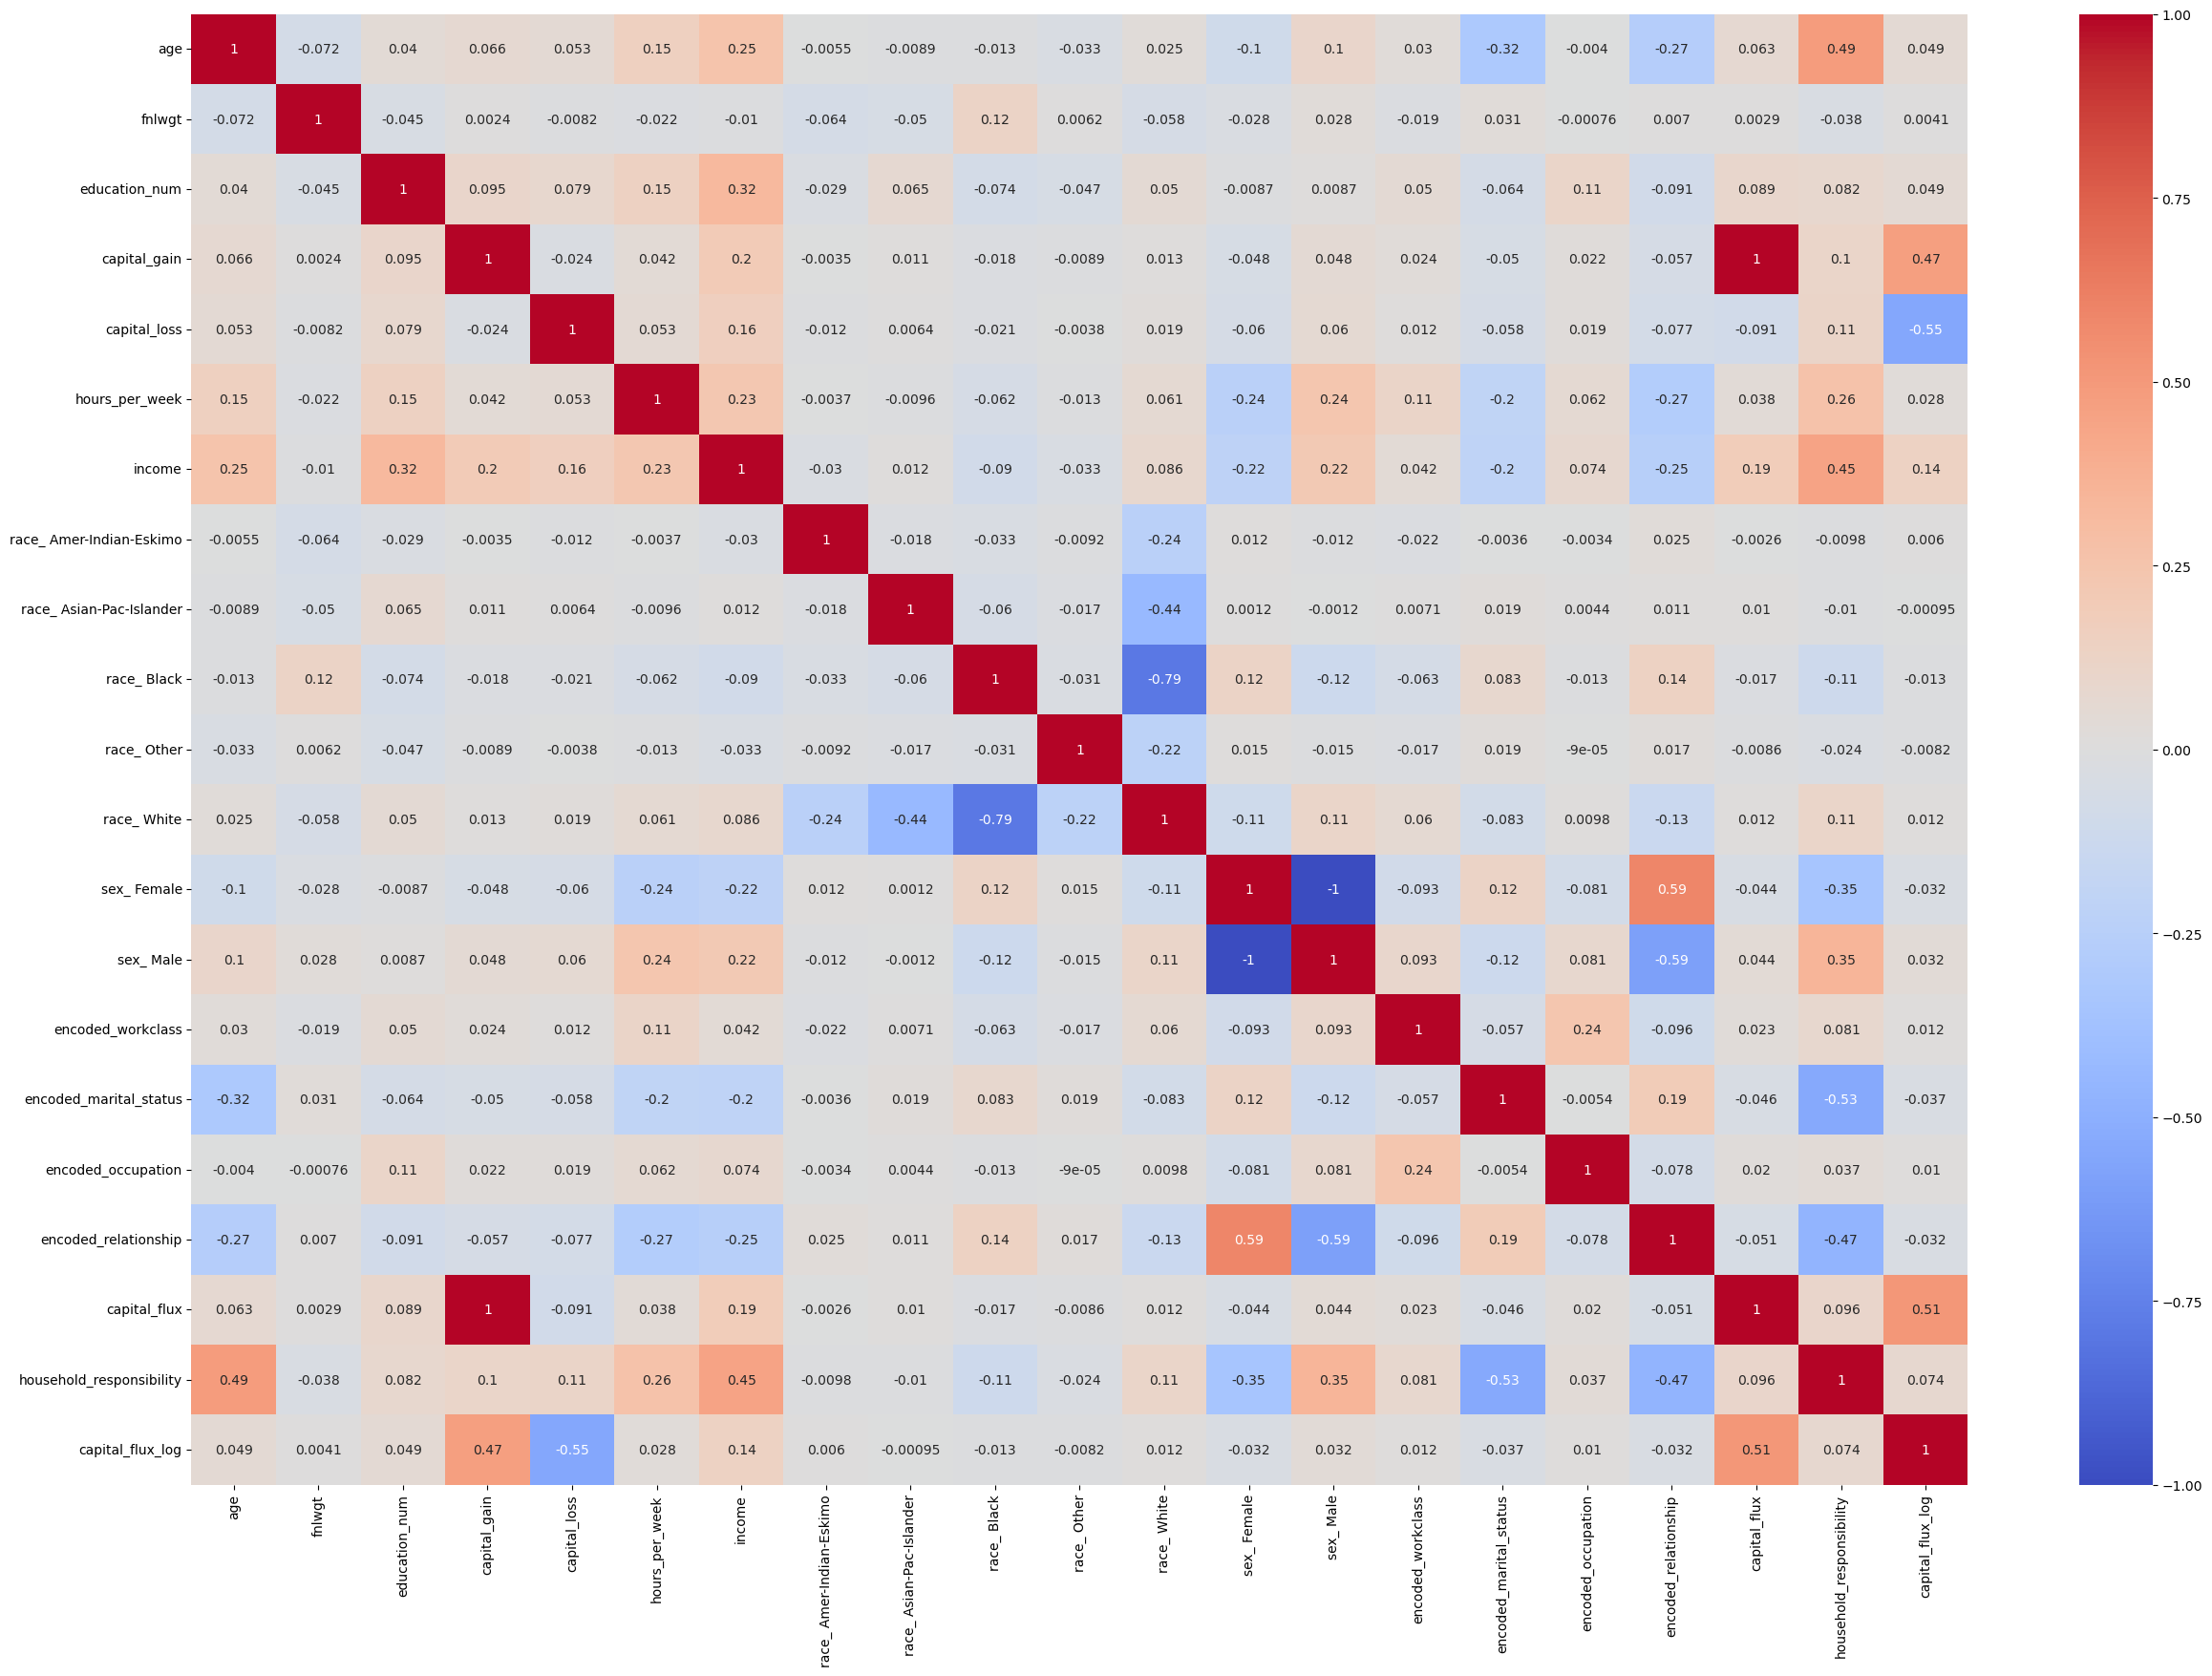

In [36]:
df_cleaned['income'] = label_encoder.fit_transform(df_cleaned['income'])

df_cleaned_num=df_cleaned.select_dtypes(include=['int64','float64'])
plt.figure(figsize=[30,20])
sns.heatmap(df_cleaned_num.corr(),annot=True,cmap='coolwarm')
plt.show()

In [31]:
#%pip install -U ppscore

In [32]:
#!pip install --upgrade pip setuptools wheel

In [33]:
#!pip install --pre ppscore

In [34]:
#import ppscore as pps
#matrix=pps.matrix(df_encoded)
#matrix